# Summary Notebook
Point to run directory and this notebook will pull relevant parameters, parameterizations, and plot important variables. Can also be pointed at the runs in `scratch`

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

### Config

In [20]:
RUN_DIR = Path("/scratch/alpine/dagr5998/MDF_1/coastalcanada_set_0001/")
year_init = 1975

In [26]:
def check_nans(ds, default=-9999):
    # check for any nans, infs, or unset values
    print(f"{'variable':12s} {'nan':>10s} {'default':>10s} {'inf':>10s} {'zero':>10s} {'total':>12s}")
    for name, da in ds.data_vars.items():
        a = da.values
        n_nan  = int(np.isnan(a).sum())
        n_sent = int(np.isclose(a, default).sum())
        n_inf  = int(np.isinf(a).sum())
        n_zero = int((a == 0).sum())
        flag = "  <--" if (n_nan or n_sent or n_inf) else ""
        print(f"{name:12s} {n_nan:>10d} {n_sent:>10d} {n_inf:>10d} {n_zero:>10d} {a.size:>12d}{flag}")

In [5]:
def read_namelist(modfile): 
    def parse(val):
        val = val.strip().rstrip(",")
        low = val.lower()
        if low in (".true.", ".false."):
            return low == ".true."
        try:
            return float(low.replace("d", "e"))
        except ValueError:
            return val.strip("'\"")          # strings stay strings

    param_dict = {}
    for line in modfile.read_text().splitlines():
        line = line.split("!")[0].strip()
        if line == '' or "=" not in line:
            continue
        k, v = line.split("=", 1)
        param_dict[k.strip()] = parse(v)
    return param_dict

In [6]:
def load_run(path):
    ds = xr.open_dataset(path/"history"/f"icepack.h.{year_init}0101.nc")
    return ds.sel(ni=3)

In [21]:
ds1 = load_run(RUN_DIR)
params = read_namelist(RUN_DIR / "icepack_in")

In [8]:
params["ksno"]

0.14

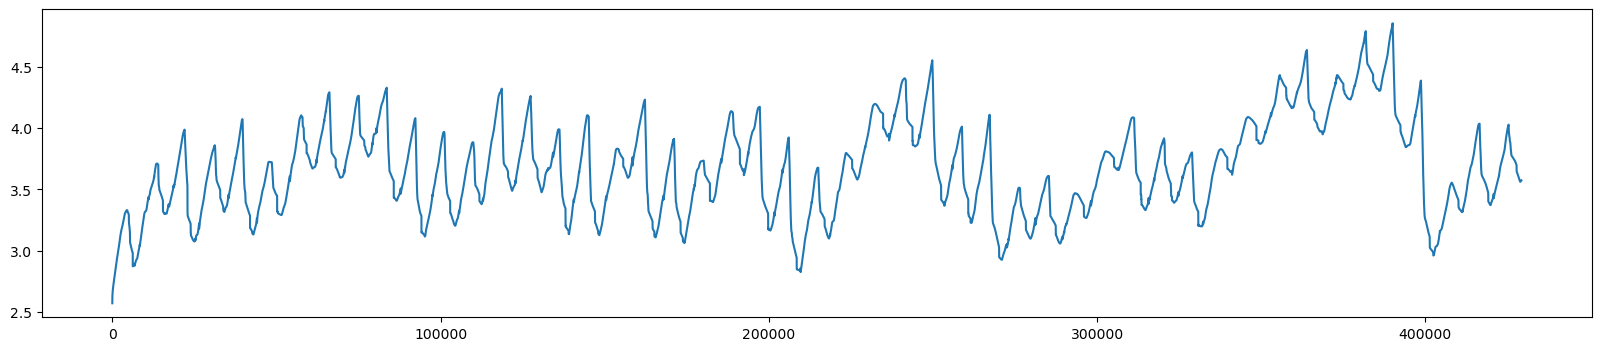

In [13]:
plt.figure(figsize = (20,4))
plt.plot(ds2["vice"]/ds2["aice"])
plt.show()

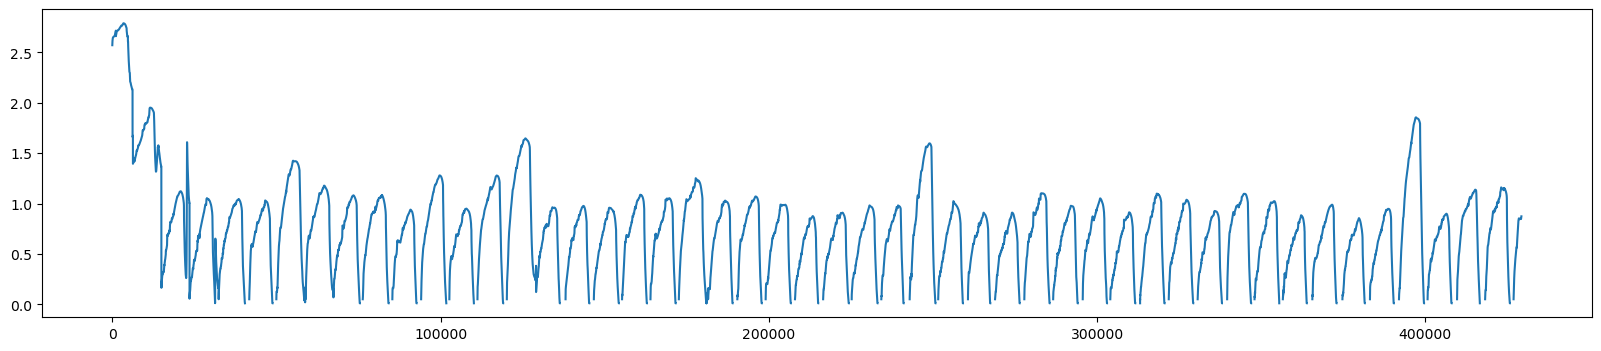

In [22]:
plt.figure(figsize = (20,4))
plt.plot(ds1["vice"]/ds1["aice"])
plt.show()

In [27]:
check_nans(ds1)

variable            nan    default        inf       zero        total
timestep              0          0          0          0       429240
date                  0          0          0          0       429240
aice                  0          0          0      53289       429240
vice                  0          0          0      53289       429240
vsno                  0          0          0      88388       429240
uvel                  0          0          0     429240       429240
vvel                  0          0          0     429240       429240
divu                  0          0          0     429240       429240
shear                 0          0          0     429240       429240
strength              0          0          0     429240       429240
evap                  0          0          0      53289       429240
fsnow                 0          0          0     144443       429240
frazil                0          0          0     415729       429240
fswabs              